1. Загрузите данные, проверьте число наблюдений и столбцов, типы данных, наличие пропущенных значений, какие уникальные значения встречаются.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as ss
import warnings
warnings.filterwarnings('ignore')

plt.style.use('Solarize_Light2')

%matplotlib inline

In [2]:
df = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_2/conversion.csv')
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB


In [4]:
#уникальные знаения
df.nunique()

ad_id                  1143
xyz_campaign_id           3
fb_campaign_id          691
age                       4
gender                    2
interest                 40
Impressions            1130
Clicks                  183
Spent                   869
Total_Conversion         32
Approved_Conversion      16
dtype: int64

In [5]:
#уникальыне знаения рекламных компаний
df.xyz_campaign_id.value_counts()

xyz_campaign_id
1178    625
936     464
916      54
Name: count, dtype: int64

In [6]:
#пропущенные знаения
df.isnull().sum()

ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64

2. Постройте график распределения числа показов (Impressions) для каждой рекламы, прологарифмировав значения.

In [7]:
log_fb = df.groupby('fb_campaign_id', as_index=False).sum()
log_fb = np.log1p(df.Impressions)
log_fb.head()

0    8.902592
1    9.790431
2    6.542472
3    8.357024
4    8.327001
Name: Impressions, dtype: float64

<Axes: xlabel='Impressions', ylabel='Density'>

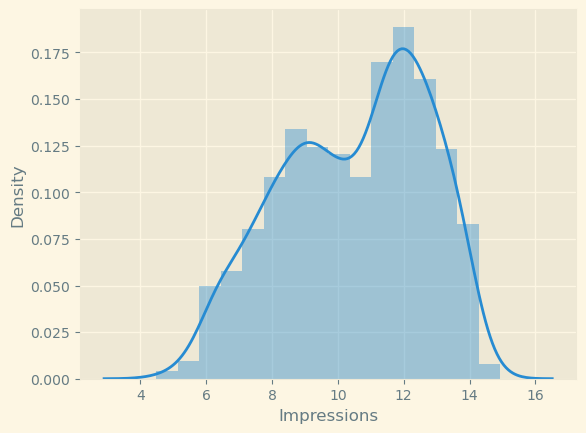

In [8]:
sns.distplot(log_fb)

3. Создайте новую колонку c CTR. Посмотрите на описательные статистики и распределение.

In [9]:
df['CTR'] =  (df.Clicks / df.Impressions * 100).round(2)
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.01
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.01
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.00
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.02
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.02


In [10]:
#описательные статистики
df['CTR'].describe()

count    1143.00000
mean        0.01643
std         0.01189
min         0.00000
25%         0.01000
50%         0.02000
75%         0.02000
max         0.11000
Name: CTR, dtype: float64

<Axes: >

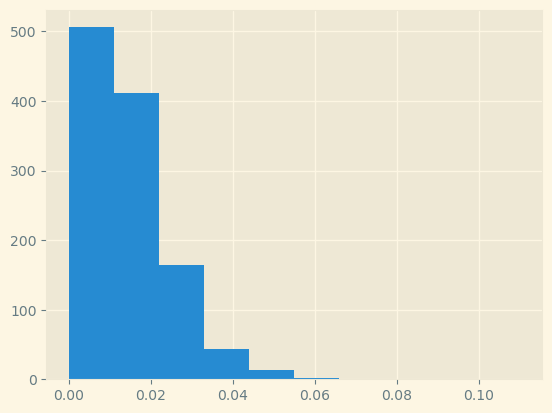

In [11]:
#распределение
df['CTR'].hist()

4. Проанализируйте CTR с разбивкой по рекламной кампании.

In [12]:
df.xyz_campaign_id.unique()

array([ 916,  936, 1178], dtype=int64)

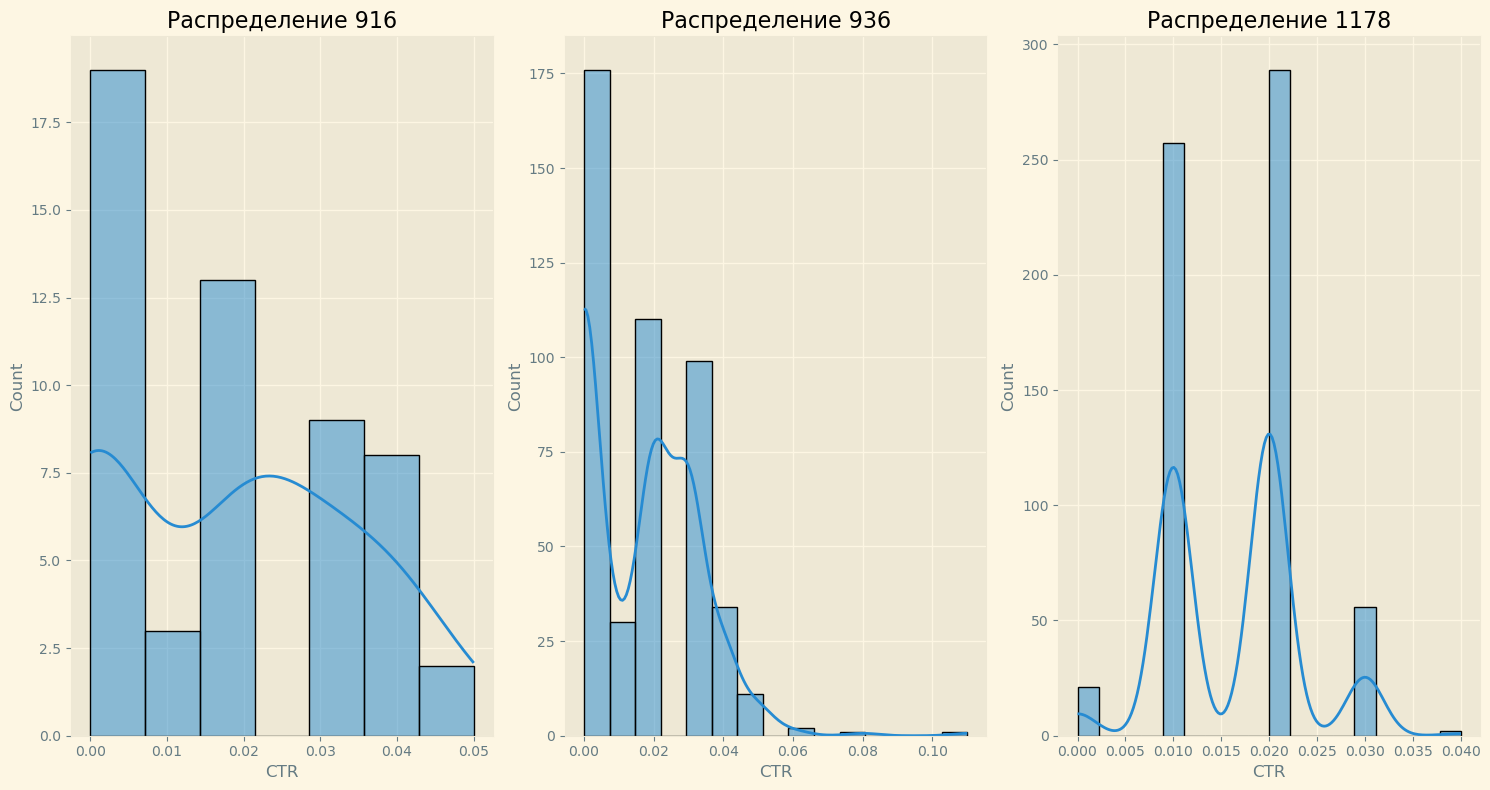

In [ ]:
# Создаем подграфики
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Строим графики распределения для каждого столбца
sns.histplot(df.query('xyz_campaign_id == 916').CTR, kde=True, ax=axes[0])
axes[0].set_title('Распределение 916')

sns.histplot(df.query('xyz_campaign_id == 936').CTR, kde=True, ax=axes[1])
axes[1].set_title('Распределение 936')

sns.histplot(df.query('xyz_campaign_id == 1178').CTR, kde=True, ax=axes[2])
axes[2].set_title('Распределение 1178')

# Показываем графики
plt.tight_layout()
plt.show()


5. Посчитайте стоимость за клик пользователя по объявлению (CPC). Изучите полученные значения, используя меры центральной тенденции и меры изменчивости. 

**CPC (cost-per-click) – стоимость за клик пользователя по объявлению. Рассчитывается путём деления суммы потраченных денег на общее число кликов:**

CPC= spent / clicks

**Выведите описательные статистики для новой переменной, посмотрите на форму распределения.



In [17]:
df['CPC'] =  (df.Spent / df.Clicks * 100).round(2)
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,CTC,CPC
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1,0.01,143.0,143.0
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0,0.01,91.0,91.0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0,0.00,NaN,NaN
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0,0.02,125.0,125.0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1,0.02,129.0,129.0


In [18]:
# Меры центральной тенденции
mean_cpc = df['CPC'].mean()
median_cpc = df['CPC'].median()
mode_cpc = df['CPC'].mode()[0]  # Получаем первый моду

# Меры изменчивости
std_cpc = df['CPC'].std()  # Стандартное отклонение
var_cpc = df['CPC'].var()   # Дисперсия
min_cpc = df['CPC'].min()   # Минимальное значение
max_cpc = df['CPC'].max()   # Максимальное значение
range_cpc = max_cpc - min_cpc    # Размах


In [21]:

# Вывод результатов
print(f"Среднее значение CPC: {mean_cpc:.2f}")
print(f"Медиана CPC: {median_cpc:.2f}")
print(f"Модус CPC: {mode_cpc:.2f}")
print(f"Стандартное отклонение CPC: {std_cpc:.2f}")
print(f"Дисперсия CPC: {var_cpc:.2f}")
print(f"Минимальное значение CPC: {min_cpc:.2f}")
print(f"Максимальное значение CPC: {max_cpc:.2f}")
print(f"Размах CPC: {range_cpc:.2f}")



Среднее значение CPC: 149.93
Медиана CPC: 149.82
Модус CPC: 154.00
Стандартное отклонение CPC: 23.29
Дисперсия CPC: 542.33
Минимальное значение CPC: 18.00
Максимальное значение CPC: 221.20
Размах CPC: 203.20


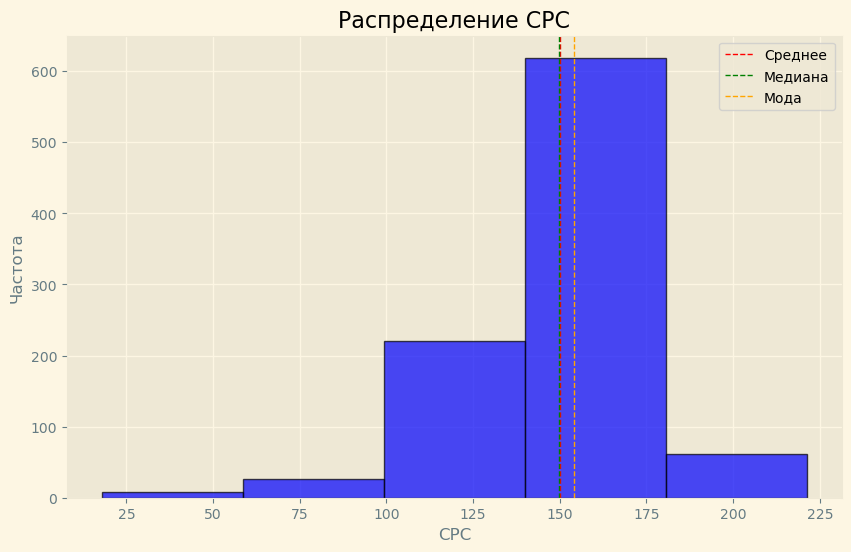

In [23]:
# Визуализация
plt.figure(figsize=(10,6))
plt.hist(df['CPC'], bins=5, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(mean_cpc, color='red', linestyle='dashed', linewidth=1, label='Среднее')
plt.axvline(median_cpc, color='green', linestyle='dashed', linewidth=1, label='Медиана')
plt.axvline(mode_cpc, color='orange', linestyle='dashed', linewidth=1, label='Мода')
plt.title('Распределение CPC')
plt.xlabel('CPC')
plt.ylabel('Частота')
plt.legend()
plt.show()

6. Визуализируйте CPC с разбивкой по полу пользователей, которым были показаны объявления. 

In [26]:
cpc_gender = df.groupby('gender').CPC.sum()
cpc_gender

gender
F    66162.67
M    74176.32
Name: CPC, dtype: float64

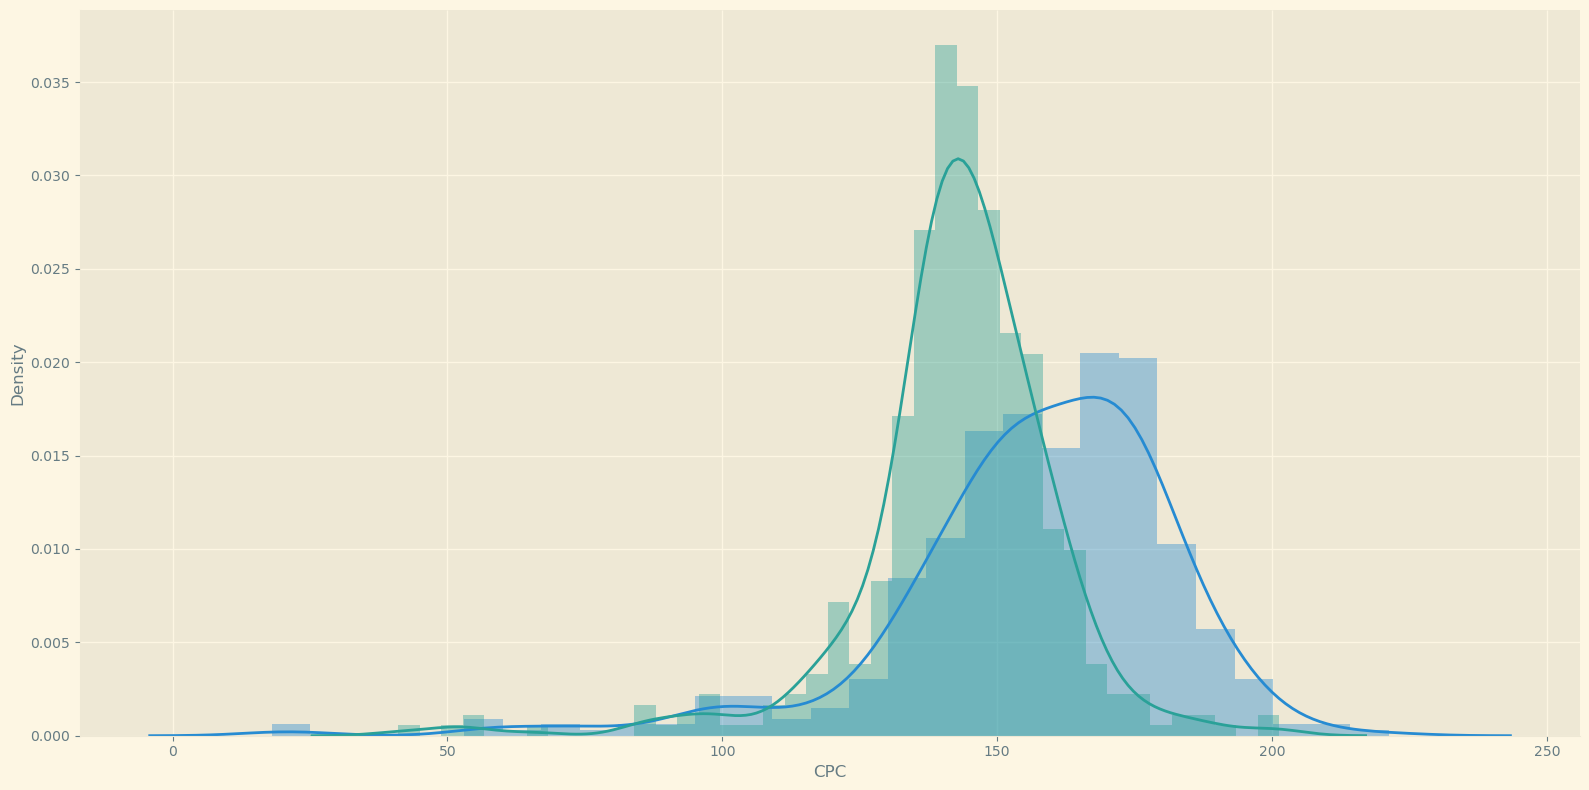

In [34]:
plt.figure(figsize=(16,8))
sns.distplot(df.query("gender == 'M'").dropna().CPC)
sns.distplot(df.query("gender == 'F'").dropna().CPC)
plt.tight_layout()
sns.despine()

7. Посчитайте конверсию из клика в покупку.

**Конверсия (conversion rate) – отношение числа пользователей, совершивших целевое действие на определенном этапе, к общему числу тех, кто дошел до данного этапа.**

<Axes: ylabel='conversion_rate'>

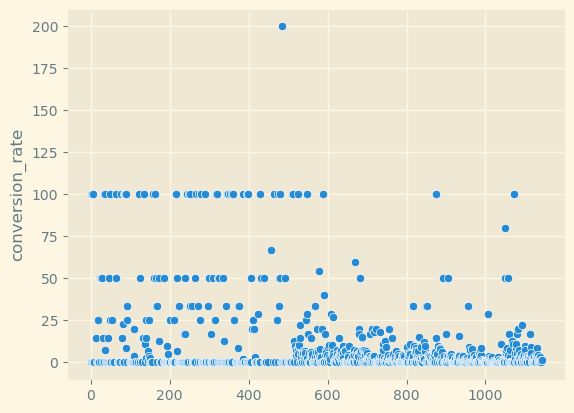

In [44]:
df['conversion_rate'] = (df.Approved_Conversion / df.Clicks * 100).round(2)
sns.scatterplot(df['conversion_rate'].dropna())

In [46]:
df.query('conversion_rate == 200')

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion,CTR,CTC,CPC,conversion_rate
484,951391,936,123659,30-34,F,28,2879,1,1.59,2,2,0.03,159.0,159.0,200.0


Аномальные данные у объявления 951391, при 1 клике значение Approved_Conversion равна 2